# Proyecto de Análisis Logístico: Importaciones de Fertilizantes Nitrogenados 2024

## 1. Descripción y Contexto
A continuación se presenta un análisis detallado de las importaciones de fertilizantes nitrogenados (Familia HS Code 3102) en México durante el año 2024. El objetivo es identificar patrones estacionales, dependencia logística y oportunidades de optimización de costos para la cadena de suministro agrícola.

**Fuente de Datos:** Información obtenida de Panjiva | S&P Global | Market Intelligence (https://es.panjiva.com/). La base de datos contiene registros aduanales detallados incluyendo consignatarios, puertos de entrada, volúmenes y valores CIF.

## 2. Objetivos del Proyecto

### Parte A: Resolución de Caso Técnico 
Se dará respuesta a las preguntas clave planteadas por la gerencia:
1.  **Volumen Mensual:** Calcular la importación total de productos nitrogenados mes a mes.
2.  **Auditoría de Cliente:** Calcular la importación específica para "Agroindustrias del Balsas SA de CV".
3.  **Producto Estratégico:** Obtener el total anual de UREA (HS 3102.1).
4.  **Líderes del Mercado:** Identificar el Top 5 de consignatarios por volumen.
5.  **Volumen por Entidad:** Obtener el volumen de entrada por importación de nitrogenados por Entidad Federativa en 2024.

### Parte B: Fases de Análisis "Ciencia de Datos"
* **Ingeniería de Variables:** Creación de métricas de negocio (Precio Unitario, Segmentación).
* **Análisis Exploratorio de Datos (EDA)** Mapas de calor logísticos y distribución de costos.
* **Modelado Predictivo** Algoritmos para estimación de precios.

---

## Preparación del Entorno y Limpieza de Datos
Para garantizar la integridad de los cálculos en los ejercicios posteriores, comenzamos con la **Ingeniería de Datos**.
1.  **Carga:** Importación de librerías y lectura del dataset.
2.  **Limpieza:** Estandarización de fechas, conversión de variables numéricas, rellenar o eliminar valores faltantes y saneamiento de textos.
3.  **Validación:** Verificación de tipos de datos antes del análisis.

---

In [3]:
# 1. IMPORTACIÓN DE LIBRERÍAS 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [4]:
!pip install openpyxl
!"{sys.executable}" -m pip install openpyxl


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /Users/cesardudleycastellanosnieto/Desktop/TT/entornos/insurance_data_modeling/venv/bin/python -m pip install --upgrade pip


In [5]:
# Definimos el archivo a trabajar
print(os.getcwd())   # carpeta actual
print(os.listdir())  # qué archivos/carpetas hay aquí
path = "Ejercicio Entrevista GOF.xlsx"

/Users/cesardudleycastellanosnieto/PEMEX
['Ejercicio Entrevista GOF.xlsx', '.ipynb_checkpoints', 'GOF.ipynb']


In [6]:
# Cargamos los datos desde la fila correspondinete
df = pd.read_excel(path, sheet_name="Importaciones HS Code 3102", header=2)
df.head()

,﻿Shipment Date,Etiqueta (s) correspondiente (s),Consignatario,Roles Comerciales del Consignatario,Expedidor,Shipper Profile,Roles Comerciales del Proveedor,Item Origin,Port of Unlading (Original Format),Método de transporte,Gross Weight (kg),Gross Weight (t),Gross Weight (Original Format),Freight Value (MXN),Exchange Rate (MXN-USD),Código HS,Mercancías enviadas,"Value of Goods, Item CIF (USD)"
0,2024-01-02,HS Code (4-digit): 3102,Logistica Y Asesoria Aduanera R&R Y Asociados ...,Logistics,Musket Corporation,https://panjiva.com/Musket-Corporation/175102312,Manufacturer,United States,"NUEVO LAREDO, NUEVO LAREDO, TAMAULIPAS.",Rail,81647.0,81.647,571529.0,NaN,16.89,3102909100,FERTILIZANTE AGRICOLA LIQUIDO,6200.02
1,2024-01-02,HS Code (4-digit): 3102,Logistica Y Asesoria Aduanera R&R Y Asociados ...,Logistics,Musket Corporation,https://panjiva.com/Musket-Corporation/175102312,Manufacturer,United States,"NUEVO LAREDO, NUEVO LAREDO, TAMAULIPAS.",Rail,81647.0,81.647,571529.0,NaN,16.89,3102909100,FERTILIZANTE AGRICOLA LIQUIDO,6200.02
2,2024-01-02,HS Code (4-digit): 3102,Servicios Nh3 Sa De Cv,NaN,J.R. Simplot Co.,https://panjiva.com/J-R-Simplot-Co/32894015,NaN,United States,"MEXICALI, MEXICALI, BAJA CALIFORNIA.",Truck,23633.0,23.633,23633.0,9682.0,16.89,3102800100,FERTILIZANTE LIQUIDO A BASE DE UREA Y NITRATO ...,10211.62
3,2024-01-02,HS Code (4-digit): 3102,Impulsora Agricola De Matamoros Sa De Cv,NaN,Helena Agri Enterprises Llc,https://panjiva.com/Helena-Agri-Enterprises-Ll...,NaN,United States,"MATAMOROS, MATAMOROS, TAMAULIPAS.",Truck,20984.0,20.984,20984.0,8447.0,16.89,3102909100,ABONO QUIMICO NITROGENADO CONSTITUIDO POR UNA ...,7031.40
4,2024-01-02,HS Code (4-digit): 3102,Logistica Y Asesoria Aduanera R&R Y Asociados ...,Logistics,Musket Corporation,https://panjiva.com/Musket-Corporation/175102312,Manufacturer,United States,"NUEVO LAREDO, NUEVO LAREDO, TAMAULIPAS.",Rail,81647.0,81.647,571529.0,NaN,16.89,3102909100,FERTILIZANTE AGRICOLA LIQUIDO,6200.02


In [7]:
# Mostramos el nombre de todas las columnas
print("Nombres de columnas")
print(df.columns.tolist())  

print()

# Mostramos los tipos de datos 
print("Tipos de datos")
df.info()


Nombres de columnas
['\ufeffShipment Date', 'Etiqueta (s) correspondiente (s)', 'Consignatario', 'Roles Comerciales del Consignatario', 'Expedidor', 'Shipper Profile', 'Roles Comerciales del Proveedor', 'Item Origin', 'Port of Unlading (Original Format)', 'Método de transporte', 'Gross Weight (kg)', 'Gross Weight (t)', 'Gross Weight (Original Format)', 'Freight Value (MXN)', 'Exchange Rate (MXN-USD)', 'Código HS', 'Mercancías enviadas', 'Value of Goods, Item CIF (USD)']

Tipos de datos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19878 entries, 0 to 19877
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   ﻿Shipment Date                       19878 non-null  datetime64[ns]
 1   Etiqueta (s) correspondiente (s)     19878 non-null  object        
 2   Consignatario                        19763 non-null  object        
 3   Roles Comerciales del Consigna

In [8]:
# Arreglar el nombre raro de la columna de fecha
df = df.rename(columns={'\ufeffShipment Date': 'Shipment Date'})
#Llenamos los valores nulos críticos en la columna Consignatario  
df['Consignatario']= df['Consignatario'].fillna('DESCONOCIDO')
#Ajustamos el Dtype de Código HS a string para poder agruparlos por familias y facilitar en anális
df['Código HS']= df['Código HS'].astype(str)

## Ejercicio 1

Volumen Mensual: Calcular la importación total de productos nitrogenados mes a mes.

In [10]:
df["Shipment Date"] = pd.to_datetime(df["Shipment Date"])
df["Mes"] = df["Shipment Date"].dt.to_period("M")
#Filtramos los valores de 2024
df_2024 = df[df["Shipment Date"].dt.year == 2024].copy()
#Agrupamos
importacion_mensual = (
    df_2024
      .groupby("Mes", as_index=False)["Gross Weight (t)"]
      .sum()
      .sort_values("Mes")
)

#Mostramos la tabla mensual
print("Tabla Mensual:")
print(importacion_mensual)
print()

#Total anual
print("Total importaciones de productos nitrogenados en 2024:")
total_volumen = importacion_mensual["Gross Weight (t)"].sum()
print(f"{total_volumen:,.2f} Toneladas")

Tabla Mensual:
        Mes  Gross Weight (t)
0   2024-01      184380.45107
1   2024-02      228063.36008
2   2024-03      231659.42214
3   2024-04      581096.86218
4   2024-05      434758.20553
5   2024-06      543354.12891
6   2024-07      184675.35099
7   2024-08      199688.34623
8   2024-09       80544.08505
9   2024-10      200232.39507
10  2024-11      169589.16366
11  2024-12      314797.11827

Total importaciones de productos nitrogenados en 2024:
3,352,838.89 Toneladas


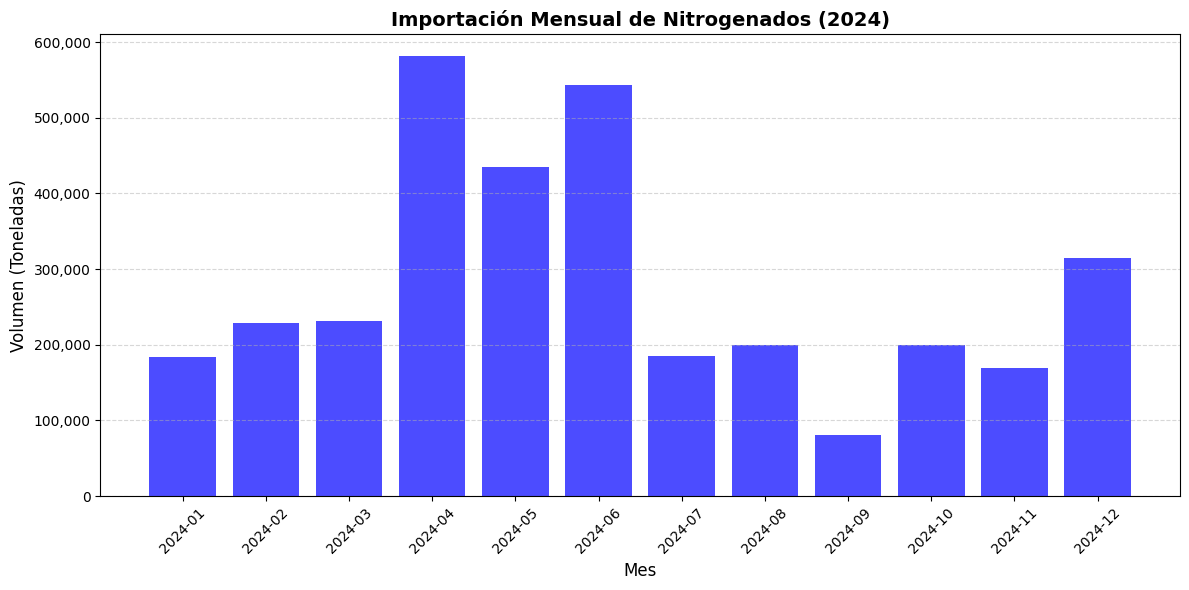

In [11]:
#Graficamos
importacion_mensual["Mes_Str"] = importacion_mensual["Mes"].astype(str)
plt.figure(figsize=(12, 6))
plt.bar(importacion_mensual['Mes_Str'], importacion_mensual['Gross Weight (t)'], color='blue', alpha=0.7)
plt.title('Importación Mensual de Nitrogenados (2024)', fontsize=14, fontweight='bold')
plt.ylabel('Volumen (Toneladas)', fontsize=12)
plt.xlabel('Mes', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

### Hallazgos Clave

Al analizar el volumen mensual de importación de nitrogenados, identificamos tres patrones claros que responden a la lógica agrícola nacional:

1.  **El Pico de Demanda (Abril - Junio):**
Se registra un incremento sustancial en las importaciones durante el segundo trimestre, siendo estos los meses de mayor volumen.
sto coincide con la ventana de preparación y fertilización del **Ciclo Agrícola Primavera-Verano**, el más importante del país. Los productores aseguran el insumo justo antes de la temporada de lluvias para maximizar el rendimiento de la siembra.

2.  **Caída de la demanda en Septiembre:**
Septiembre presenta el nivel más bajo de importación en todo el año.
Marca el fin de la ventana de fertilización del ciclo principal. Para este punto, la mayoría de los cultivos ya están en etapa de maduración o cosecha, por lo que la demanda de Urea cae drásticamente.

3.  **Repunte Invernal (Diciembre):**
Se aprecia un ligero aumento al cierre del año, aunque menor comparado con el verano.
Responde al inicio del **Ciclo Otoño-Invierno** (principalmente en el norte y noroeste del país) y a estrategias de compra anticipada para asegurar inventario al inicio del siguiente año fiscal.

## Ejercicio 2
Auditoría de Cliente: Calcular la importación específica para "Agroindustrias del Balsas SA de CV".

In [14]:
df_2024["Consignatario_norm"] = df_2024["Consignatario"].str.strip().str.upper()

nombre_balsas = "AGROINDUSTRIAS DEL BALSAS SA DE CV"

df_balsas = df_2024[df_2024["Consignatario_norm"] == nombre_balsas].copy()

importacion_balsas_mensual = (
    df_balsas
      .groupby("Mes", as_index=False)["Gross Weight (t)"]
      .sum()
      .sort_values("Mes")
)

#Creamos los meses faltantes
todos_los_meses = pd.period_range(start='2024-01', end='2024-12', freq='M')
importacion_balsas_mensual = importacion_balsas_mensual.set_index('Mes')
importacion_balsas_mensual = importacion_balsas_mensual.reindex(todos_los_meses, fill_value=0)
importacion_balsas_mensual = importacion_balsas_mensual.reset_index().rename(columns={'index': 'Mes'})

#Mostramos la tabla mensual
print("Tabla Mensual:")
print(importacion_balsas_mensual)
print()

#Total anual
print("Total importaciones de productos nitrogenados Agroindustrias del Balsas SA de CV en 2024:")
total_volumen_balsas = importacion_balsas_mensual["Gross Weight (t)"].sum()
print(f"{total_volumen_balsas:,.2f} Toneladas")

Tabla Mensual:
        Mes  Gross Weight (t)
0   2024-01       21786.62500
1   2024-02        8488.05000
2   2024-03           0.00000
3   2024-04      155281.37200
4   2024-05       24499.77700
5   2024-06        5037.00000
6   2024-07           0.00074
7   2024-08       17599.99600
8   2024-09           0.00000
9   2024-10           0.00000
10  2024-11           0.00000
11  2024-12           0.00000

Total importaciones de productos nitrogenados Agroindustrias del Balsas SA de CV en 2024:
232,692.82 Toneladas


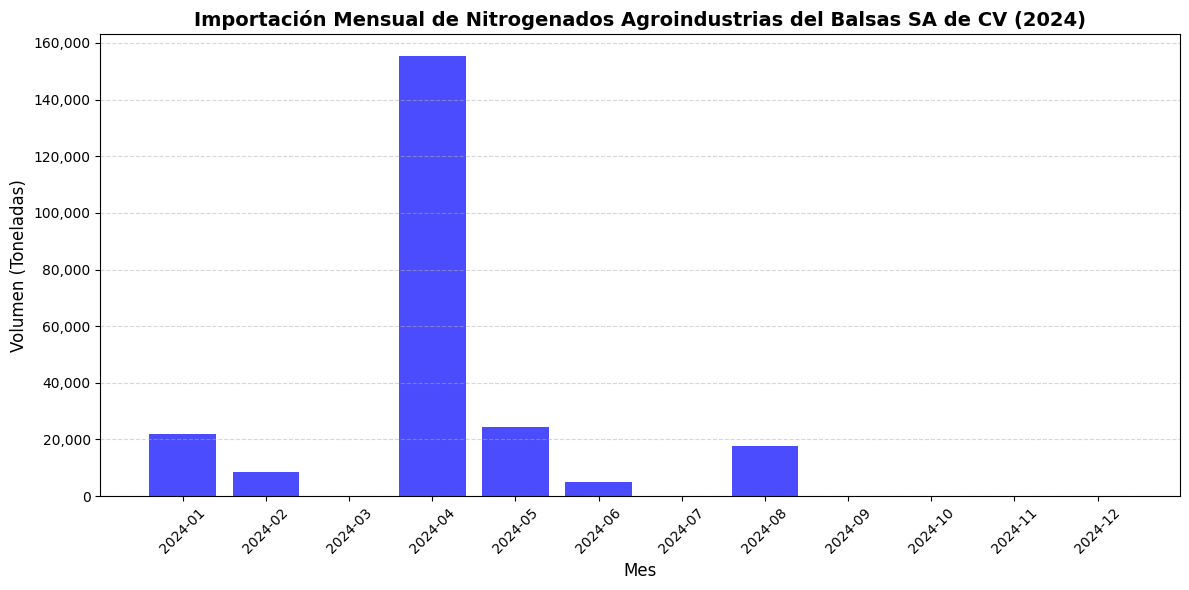

In [15]:
#Graficamos
importacion_balsas_mensual["Mes_agro"] = importacion_balsas_mensual["Mes"].astype(str)
plt.figure(figsize=(12, 6))
plt.bar(importacion_balsas_mensual["Mes_agro"], importacion_balsas_mensual['Gross Weight (t)'], color='blue', alpha=0.7)
plt.title('Importación Mensual de Nitrogenados Agroindustrias del Balsas SA de CV (2024)', fontsize=14, fontweight='bold')
plt.ylabel('Volumen (Toneladas)', fontsize=12)
plt.xlabel('Mes', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

### Hallazgos Clave

Al aislar el comportamiento de este cliente estratégico, detectamos un patrón logístico altamente especializado:

1.  **Pico Logístico Estratégico (Abril):**
Existe una diferencia abismal en el volumen de importación de Abril (pico máximo) comparado con el resto del año. La empresa concentra la gran mayoría de su entrada anual en un solo mes.
Este comportamiento obedece estrictamente al abastecimiento para el **Ciclo Agrícola Primavera-Verano**. A diferencia de otros importadores que mantienen flujo constante, Agroindustrias del Balsas ejecuta una estrategia de compra masiva anticipada ("Golpe de Stock") para tener producto disponible justo cuando arranca la siembra masiva en el país.

## Ejercicio 3
Producto Estratégico: Obtener el total anual de UREA (HS 3102.1).

In [18]:
# Filtramos la Urea
df_urea = df_2024[df_2024["Código HS"].astype(str).str.startswith("31021")].copy()
#Urea mensual
urea_mensual = (
    df_urea
      .groupby("Mes", as_index=False)["Gross Weight (t)"]
      .sum()
      .sort_values("Mes")
)
print("Tabla Mensual:")
print(urea_mensual)
print()
# Total anual de urea en toneladas
urea_anual_t = df_urea["Gross Weight (t)"].sum()
print("Importación anual de Urea 2024 (t):")
print(f"{urea_anual_t:,.2f} Toneladas")

Tabla Mensual:
        Mes  Gross Weight (t)
0   2024-01       69916.29524
1   2024-02      139813.70413
2   2024-03      107288.73150
3   2024-04      370824.52778
4   2024-05      280601.96298
5   2024-06      286695.17229
6   2024-07      114222.10326
7   2024-08      127867.88213
8   2024-09       25444.09502
9   2024-10      125671.75833
10  2024-11       63466.82945
11  2024-12        8657.71977

Importación anual de Urea 2024 (t):
1,720,470.78 Toneladas


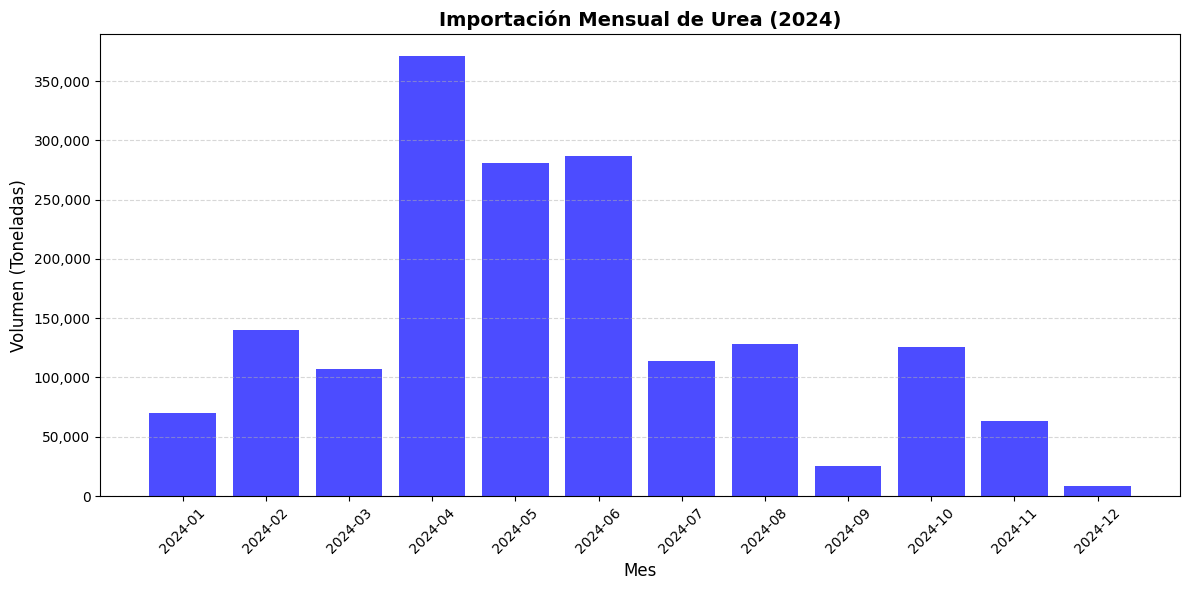

In [19]:
#Graficamos
urea_mensual["Mes_agro"] = urea_mensual["Mes"].astype(str)
plt.figure(figsize=(12, 6))
plt.bar(urea_mensual["Mes_agro"], urea_mensual['Gross Weight (t)'], color='blue', alpha=0.7)
plt.title('Importación Mensual de Urea (2024)', fontsize=14, fontweight='bold')
plt.ylabel('Volumen (Toneladas)', fontsize=12)
plt.xlabel('Mes', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

## Ejercicio 4
Líderes del Mercado: Identificar el Top 5 de consignatarios por volumen.

In [21]:
top5_consignatarios = (
    df_2024
      .groupby("Consignatario", as_index=False)["Gross Weight (t)"]
      .sum()
      .sort_values("Gross Weight (t)", ascending=False)
      .head(5)
)

top5_consignatarios

,Consignatario,Gross Weight (t)
205,Productora De Fertilizantes Del Noroeste Sa De Cv,434896.14690
113,Fertilizantes Y Nutrientes De Occidente Sa De Cv,308090.38500
266,Yara Mexico S De Rl De Cv,303738.92770
24,Agroindustrias Del Balsas Sa De Cv,232692.82074
159,Logistica Comercial International Delta S.A. D...,223515.51200


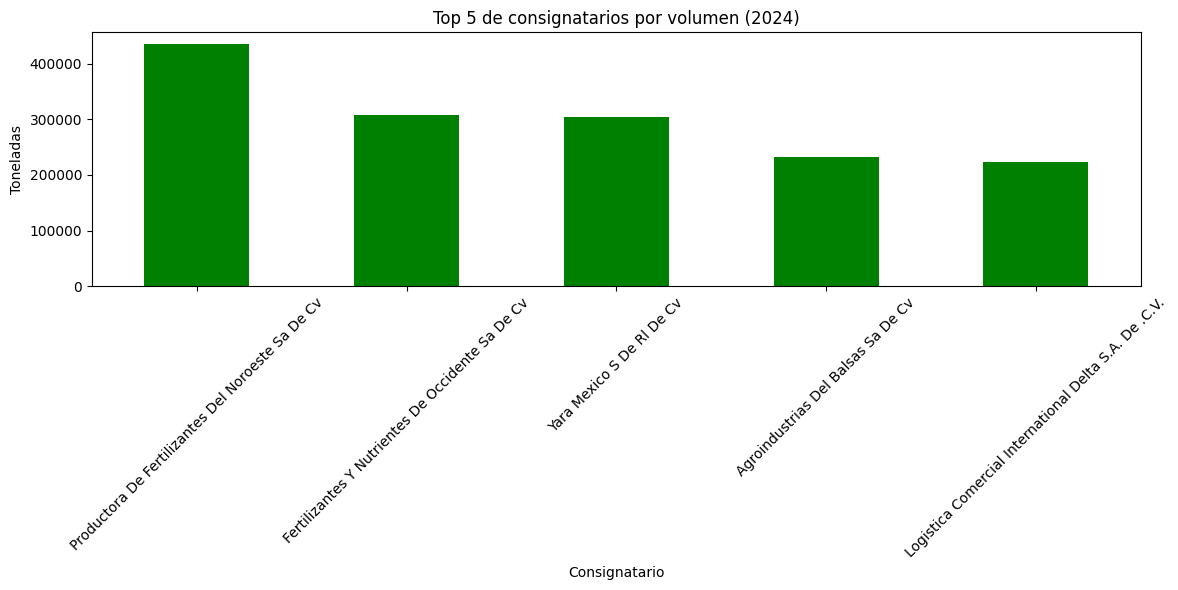

In [22]:
#Graficamos
plt.figure(figsize=(12, 6))
top5_consignatarios.plot(x='Consignatario', y='Gross Weight (t)', kind='bar', color='green', legend=False, ax=plt.gca())
plt.title('Top 5 de consignatarios por volumen (2024)')
plt.ylabel('Toneladas')
plt.xlabel('Consignatario')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Ejercicio 5
Volumen por Entidad Obtener el volumen de entrada por importación de nitrogenados por Entidad Federativa en 2024.

In [24]:
#Mostramos algunos ejemplos de los datos para darnos una idea de como estan construidas las entradas
df_2024["Port of Unlading (Original Format)"].sample(5)

15408    LUCIO BLANCO-LOS INDIOS, MATAMOROS, TAMAULIPAS.
18669          PIEDRAS NEGRAS, PIEDRAS NEGRAS, COAHUILA.
10381                          NOGALES, NOGALES, SONORA.
10152           CIUDAD JUAREZ, CIUDAD JUAREZ, CHIHUAHUA.
743              NUEVO LAREDO, NUEVO LAREDO, TAMAULIPAS.
Name: Port of Unlading (Original Format), dtype: object

In [25]:
#Seleccionaremos solo la última parte que indica el Estado
df_2024["Estado"] = (
    df_2024["Port of Unlading (Original Format)"]
      .astype(str) #La trabajamos como string
      .str.split(",") #Indicamos separación por comas
      .str[-1]  #Ignoramos el punto final
      .str.replace(".", "", regex=False)
      .str.strip()
)

In [26]:
# Conteo de toneladas por Estado
volumen_por_estado = (
    df_2024
    .groupby("Estado")["Gross Weight (t)"]
    .sum()
    .sort_values(ascending=False)
)

volumen_por_estado

Estado
COLIMA                                             789793.44696
TAMAULIPAS                                         744431.49375
VERACRUZ                                           692951.52063
SINALOA                                            552262.92213
SONORA                                             147977.90733
CHIHUAHUA                                          127941.89594
COAHUILA                                            98052.94295
BAJA CALIFORNIA                                     89372.87751
MICHOACAN                                           88218.15500
AEROPUERTO INTERNACIONAL DE LA CIUDAD DE MEXICO     13462.32316
OAXACA                                               6999.77700
NUEVO LEON                                            943.85204
YUCATAN                                               307.24800
ESTADO DE MEXICO                                      100.17564
QUINTANA ROO                                           10.47263
PUEBLA                           

In [27]:
#Notamos que tenemos 2 datos que pueden ragruparse en CIUDAD DE MEXICO
reemplazos = {
    "AEROPUERTO INTERNACIONAL DE LA CIUDAD DE MEXICO": "CIUDAD DE MEXICO",
    "DISTRITO FEDERAL": "CIUDAD DE MEXICO"
}
# Creamos columna ajustada aplicando el reemplazo
df_2024["Estado_ajustado"] = df_2024["Estado"].replace(reemplazos)
#Agrupación Final
volumen_por_estado_final = (
    df_2024
    .groupby("Estado_ajustado", as_index=False)["Gross Weight (t)"]
    .sum()
    .sort_values("Gross Weight (t)", ascending=False)
)
print("Volumen de entrada por importación de nitrogenados por Entidad Federativa en 2024")
print(volumen_por_estado_final.to_string(formatters={'Gross Weight (t)': '{:,.4f}'.format}))

Volumen de entrada por importación de nitrogenados por Entidad Federativa en 2024
     Estado_ajustado Gross Weight (t)
5             COLIMA     789,793.4470
16        TAMAULIPAS     744,431.4938
17          VERACRUZ     692,951.5206
14           SINALOA     552,262.9221
15            SONORA     147,977.9073
2          CHIHUAHUA     127,941.8959
4           COAHUILA      98,052.9429
0    BAJA CALIFORNIA      89,372.8775
8          MICHOACAN      88,218.1550
3   CIUDAD DE MEXICO      13,462.9040
10            OAXACA       6,999.7770
9         NUEVO LEON         943.8520
18           YUCATAN         307.2480
6   ESTADO DE MEXICO         100.1756
13      QUINTANA ROO          10.4726
11            PUEBLA           7.5092
1            CHIAPAS           3.7139
7            JALISCO           0.0737
12         QUERETARO           0.0009


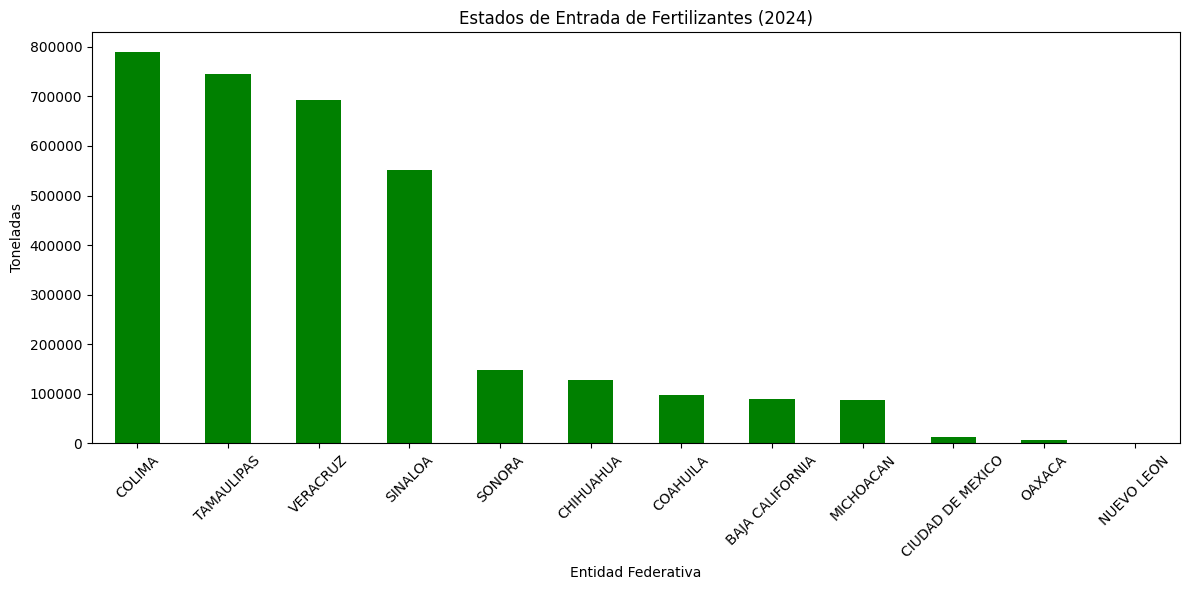

In [28]:
#Graficamos
plt.figure(figsize=(12, 6))
volumen_por_estado_final.head(12).plot(x='Estado_ajustado', y='Gross Weight (t)', kind='bar', color='green', legend=False, ax=plt.gca())
plt.title('Estados de Entrada de Fertilizantes (2024)')
plt.ylabel('Toneladas')
plt.xlabel('Entidad Federativa')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Hallazgos Clave: Distribución Regional de Nitrogenados (2024)

El análisis del volumen de entrada por Entidad Federativa revela una clara segmentación del mercado en tres niveles, validando la correlación entre infraestructura logística y zonas de alta productividad agrícola:

1.  **Los 4 principales:**
    * **Estados:** Colima, Tamaulipas, Veracruz y Sinaloa.

Estos cuatro estados concentran el volumen masivo de entrada, debido a que funcionan como las principales puertas marítimas (Pacífico y Golfo) para recibir grandes buques de Urea.

- **Tamaulipas:** Es el nodo clave para la entrada terrestre/ferroviaria desde EE.UU.

- **Sinaloa:** Destaca por ser el "Granero de México", donde la alta demanda de consumo local impulsa la importación directa.
        
        

2.  **El Bloque Secundario (Estados del norte y bajío):**
    * **Estados:** Sonora, Chihuahua, Coahuila, Baja California y Michoacán.
Mantienen un flujo constante y relevante, impulsado por la agricultura de exportación (hortalizas y frutales) del norte y occidente del país.

3.  **La Brecha de Volumen:**
A partir de este segundo bloque, la diferencia es drástica. El resto de las entidades tiene una participación marginal en la importación directa.


    * **Conclusión:** La importación de nitrogenados está altamente centralizada. El producto entra por pocos nodos estratégicos y desde ahí se distribuye al resto del territorio nacional.

## Ingeniería de Variables

In [31]:
#Mostramos valores faltantes den el df
print(df_2024.isna().sum())

Shipment Date                              0
Etiqueta (s) correspondiente (s)           0
Consignatario                              0
Roles Comerciales del Consignatario    15741
Expedidor                                288
Shipper Profile                          288
Roles Comerciales del Proveedor        16299
Item Origin                                0
Port of Unlading (Original Format)         0
Método de transporte                       0
Gross Weight (kg)                          0
Gross Weight (t)                          65
Gross Weight (Original Format)            65
Freight Value (MXN)                    13806
Exchange Rate (MXN-USD)                    0
Código HS                                  0
Mercancías enviadas                        2
Value of Goods, Item CIF (USD)             0
Mes                                        0
Consignatario_norm                         0
Estado                                     0
Estado_ajustado                            0
dtype: int

In [32]:
#Eliminamos las filas donde Gross Weight (t) es nan para que no afecte a las variables, no afectará mucho ya que solo son 65
df_2024_clean = df_2024.dropna(subset=['Gross Weight (t)']).copy()  

In [33]:
#Obtenemos el precio unitario por tonelada
df_2024_clean['Unit_Price']= df_2024_clean['Value of Goods, Item CIF (USD)']/df_2024_clean['Gross Weight (t)']

In [34]:
#Segmentamos los productos dividiendo Urea del resto de nitratos
df_2024_clean['Categoria_Producto'] = np.where(
    df_2024_clean['Código HS'].str.startswith('31021'), 
    'UREA', 
    'OTROS')
#Mostramos el df final
print(df_2024_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 19813 entries, 0 to 19877
Data columns (total 24 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Shipment Date                        19813 non-null  datetime64[ns]
 1   Etiqueta (s) correspondiente (s)     19813 non-null  object        
 2   Consignatario                        19813 non-null  object        
 3   Roles Comerciales del Consignatario  4077 non-null   object        
 4   Expedidor                            19588 non-null  object        
 5   Shipper Profile                      19588 non-null  object        
 6   Roles Comerciales del Proveedor      3579 non-null   object        
 7   Item Origin                          19813 non-null  object        
 8   Port of Unlading (Original Format)   19813 non-null  object        
 9   Método de transporte                 19813 non-null  object        
 10  Gross Weight (k

## Análisis Exploratorio de Datos (EDA)

Top Países Proveedores de nitrogenados 2024


Rank,Item Origin,Gross Weight (t),% del total
1,United States,"1,023,586.8018",30.53%
2,Russia,"709,626.3991",21.16%
3,Qatar,"473,827.6687",14.13%
4,China,"293,384.1538",8.75%
5,Netherlands,"150,342.2734",4.48%
6,Norway,"116,886.1968",3.49%
7,Malaysia,"113,806.0400",3.39%
8,Oman,"104,394.2730",3.11%
9,Nigeria,"60,428.8740",1.80%
10,Bahrain,"45,325.9770",1.35%


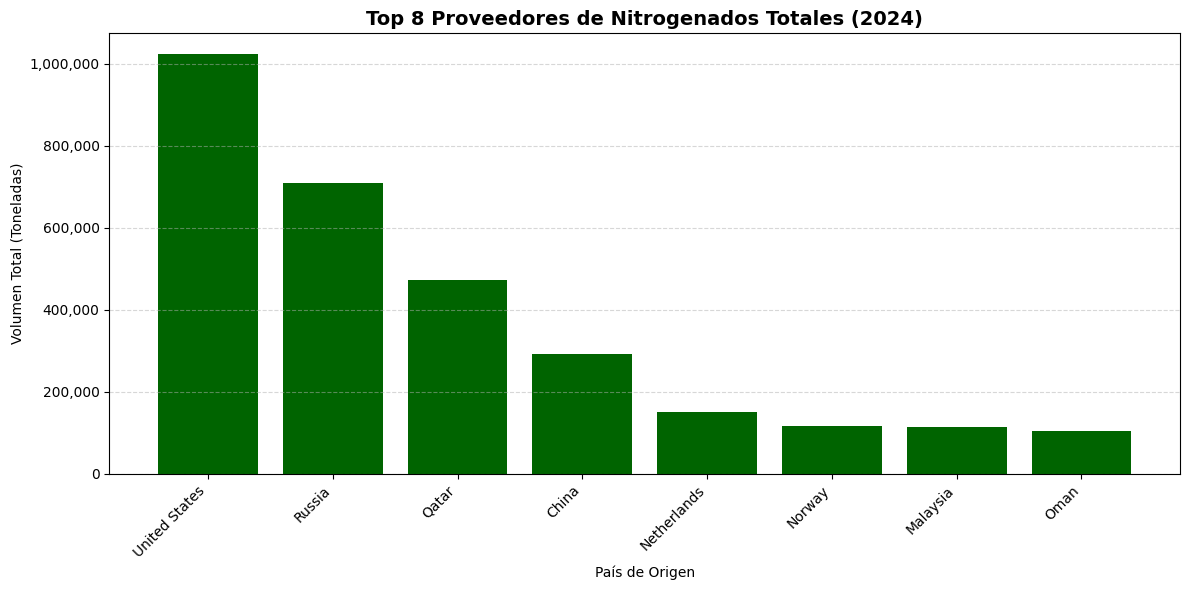

In [36]:
#Comenzamos por ver los países exportadores de nitrogenados a los que México más le compra
# Agrupamos todo el dataframe por País de Origen
tabla_nitro = (df_2024_clean
    .groupby('Item Origin', as_index=False)['Gross Weight (t)']
    .sum()
    .sort_values('Gross Weight (t)', ascending=False))

# Calculamos Ranking y Porcentaje
tabla_nitro['Rank'] = range(1, len(tabla_nitro) + 1)
tabla_nitro['% del total'] = (tabla_nitro['Gross Weight (t)'] / tabla_nitro['Gross Weight (t)'].sum() * 100)

print("Top Países Proveedores de nitrogenados 2024")
# Mostramos la tabla
display(
    tabla_nitro[['Rank', 'Item Origin', 'Gross Weight (t)', '% del total']]
    .head(10) # Mostramos top 10 en la tabla
    .style
    .format({'Gross Weight (t)': '{:,.4f}', '% del total': '{:,.2f}%'})
    .hide(axis='index')
    .background_gradient(subset=['Gross Weight (t)'], cmap='Greens')
)

print()
# Top 8 para gráfica
top8_nitro = tabla_nitro.head(8).copy()

plt.figure(figsize=(12, 6))
plt.bar(top8_nitro['Item Origin'], top8_nitro['Gross Weight (t)'], color='#006400') 

plt.title('Top 8 Proveedores de Nitrogenados Totales (2024)', fontsize=14, fontweight='bold')
plt.xlabel('País de Origen')
plt.ylabel('Volumen Total (Toneladas)')
plt.xticks(rotation=45, ha='right')

# Formato de miles en el eje Y
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Top Países Proveedores de UREA (2024)


Rank,Item Origin,Gross Weight (t),% del total
1,Russia,"669,533.9021",38.92%
2,Qatar,"473,827.6687",27.54%
3,Malaysia,"113,806.0400",6.61%
4,Oman,"104,394.2730",6.07%
5,Nigeria,"60,428.8740",3.51%
6,Bahrain,"45,325.9770",2.63%
7,Brunei Darussalam,"37,795.2350",2.20%
8,United States,"37,655.0467",2.19%
9,Trinidad and Tobago,"35,857.7200",2.08%
10,Vietnam,"35,469.6000",2.06%


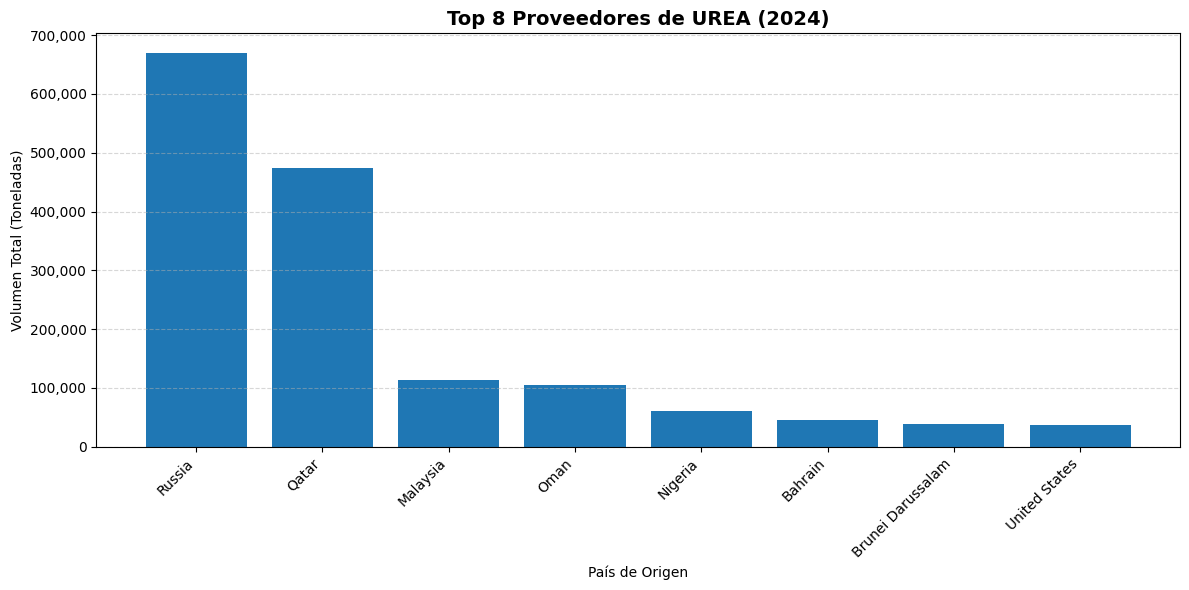

In [37]:
#Ahora nos enfocamos en los países exportadores a los que México le compra más UREA para ver sus precios y estabilidad de los mismos.

# Filtramos solo los registros de UREA
df_urea_pura = df_2024_clean[df_2024_clean['Categoria_Producto'] == 'UREA'].copy()

tabla_urea = (
    df_urea_pura
    .groupby('Item Origin', as_index=False)['Gross Weight (t)']
    .sum()
    .sort_values('Gross Weight (t)', ascending=False)
)

# Calculamos Ranking y Porcentaje
tabla_urea['Rank'] = range(1, len(tabla_urea) + 1)
tabla_urea['% del total'] = (tabla_urea['Gross Weight (t)'] / tabla_urea['Gross Weight (t)'].sum() * 100)

print("Top Países Proveedores de UREA (2024)")

# Mostramos la tabla
display(
    tabla_urea[['Rank', 'Item Origin', 'Gross Weight (t)', '% del total']]
    .head(10) # Top 10 en la tabla
    .style
    .format({'Gross Weight (t)': '{:,.4f}', '% del total': '{:,.2f}%'})
    .hide(axis='index')
    .background_gradient(subset=['Gross Weight (t)'], cmap='Blues') # Mapa de color Azul
)

# Gráfica Top 8 
top8_urea = tabla_urea.head(8).copy()

plt.figure(figsize=(12, 6))
plt.bar(top8_urea['Item Origin'], top8_urea['Gross Weight (t)'], color='#1f77b4')

plt.title('Top 8 Proveedores de UREA (2024)', fontsize=14, fontweight='bold')
plt.xlabel('País de Origen')
plt.ylabel('Volumen Total (Toneladas)')
plt.xticks(rotation=45, ha='right')

# Formato de miles en el eje Y
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

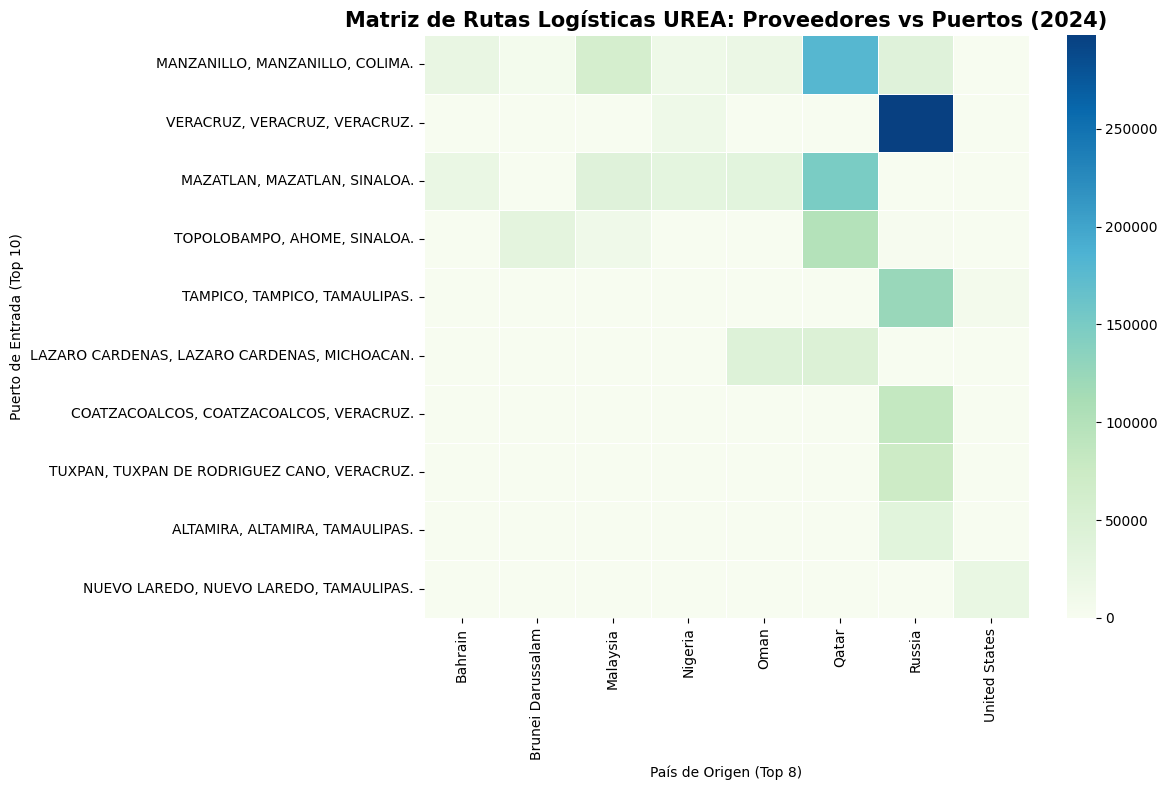

In [38]:
# MAPA DE CALOR: RUTAS LOGÍSTICAS (Origen vs Puerto)

# Identificamos el Top 8 de Países (Urea) y Top 10 Puertos
top_8_origins = df_urea_pura.groupby('Item Origin')['Gross Weight (t)'].sum().sort_values(ascending=False).head(8).index

# Creamos la Tabla Pivote
heatmap_rutas = df_urea_pura[df_urea_pura['Item Origin'].isin(top_8_origins)].pivot_table(
    index='Port of Unlading (Original Format)', 
    columns='Item Origin', 
    values='Gross Weight (t)', 
    aggfunc='sum',
    fill_value=0
)

# Filtramos solo los Top 10 Puertos 
top_10_ports = heatmap_rutas.sum(axis=1).sort_values(ascending=False).head(10).index
heatmap_rutas = heatmap_rutas.loc[top_10_ports]

# Graficamos
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_rutas, cmap='GnBu', annot=False, linewidths=.5)

plt.title('Matriz de Rutas Logísticas UREA: Proveedores vs Puertos (2024)', fontsize=15, fontweight='bold')
plt.xlabel('País de Origen (Top 8)')
plt.ylabel('Puerto de Entrada (Top 10)')

plt.tight_layout()
plt.show()

### Hallazgos Clave: Geopolítica del Suministro (2024)

El análisis comparativo de proveedores revela una clara dualidad en la dependencia del mercado mexicano, dividida por tipo de producto y zona de influencia:

1.  **Nitrogenados:**
    * **Líderes:** **Estados Unidos, Rusia y Qatar.**
Estos tres gigantes concentran más del **50% del volumen total** de nitrogenados. Su dominio no es casualidad: poseen las mayores reservas de gas natural (materia prima crítica) y una infraestructura de exportación masiva. Estados Unidos destaca en volumen general por su cercanía y diversidad de productos (mezclas/líquidos).

2.  **Urea:**
    Al aislar la Urea, la situación se radicaliza.
    * **Lideres:** **Rusia y Qatar** controlan conjuntamente cerca del **66% de la provisión nacional**.
Esto coloca al país en una situación de riesgo; ya que existe una fuerte dependencia. México depende de la estabilidad política y comercial de solo dos naciones para asegurar el fertilizante más usado en el campo.

3.  **Logística Bi-oceánica como ventaja:**
    * **Atlántico (Rusia):** El suministro ruso ingresa predominantemente por el Golfo de México (Veracruz/Coatzacoalcos), atendiendo al sureste y centro.
    * **Pacífico (Qatar):** El suministro qatarí arriba principalmente por la costa del Pacífico (Manzanillo/Topolobampo), abasteciendo al noroeste y bajío.
    * **Conclusión:** Aunque dependemos de dos países, sus rutas de entrada opuestas brindan un "seguro logístico" natural ante bloqueos o desastres naturales en un solo litoral.

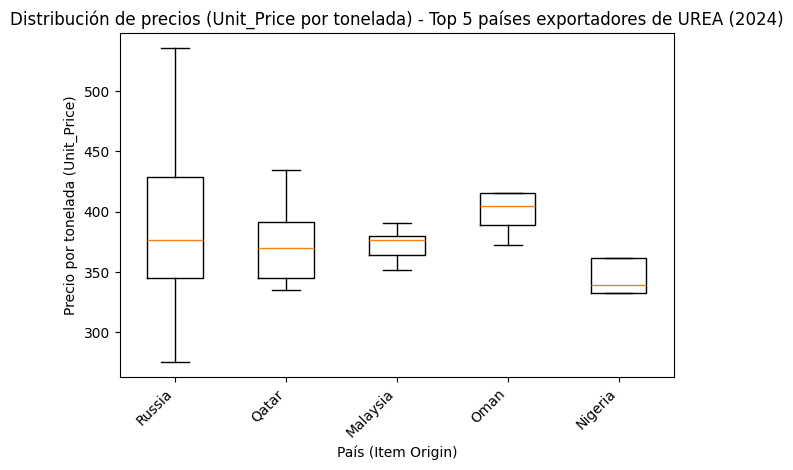

In [40]:
# Obtenemos un boxplot para comparar los precios de los principales exportadores de UREA al país
df_urea = df_2024_clean[df_2024_clean['Categoria_Producto'] == 'UREA'].copy()

df_urea['Unit_Price'] = pd.to_numeric(df_urea['Unit_Price'], errors='coerce')
df_urea['Gross Weight (t)'] = pd.to_numeric(df_urea['Gross Weight (t)'], errors='coerce')

# Nos enfocamos en el Top 5 países por volumen
top5_paises = (df_urea.groupby('Item Origin')['Gross Weight (t)']
               .sum()
               .sort_values(ascending=False)
               .head(5)
               .index)

df_top5 = df_urea[df_urea['Item Origin'].isin(top5_paises)].dropna(subset=['Unit_Price'])

# Graficamos (en el mismo orden del ranking por volumen)
data = [df_top5.loc[df_top5['Item Origin'] == pais, 'Unit_Price'].values for pais in top5_paises]

plt.figure()
plt.boxplot(data, tick_labels=list(top5_paises), showfliers=False)
plt.title('Distribución de precios (Unit_Price por tonelada) - Top 5 países exportadores de UREA (2024)')
plt.xlabel('País (Item Origin)')
plt.ylabel('Precio por tonelada (Unit_Price)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



- Los 5 países principales proveedores de UREA a México muestran medianas de precio relativamente cercanas, lo que sugiere un nivel de precio “central” similar entre proveedores.

- Rusia, siendo el mayor proveedor por volumen, presenta la mayor variabilidad (mostrando una caja y bigotes más largos), lo que significa precios menos consistentes que los otros países, aunque la dispersión no parece extrema.

- Comparativamente, algunos países (como Malasia) muestran cajas más compactas, indicando mayor estabilidad en precios; mientras otros tienen una dispersión un poco mayor.

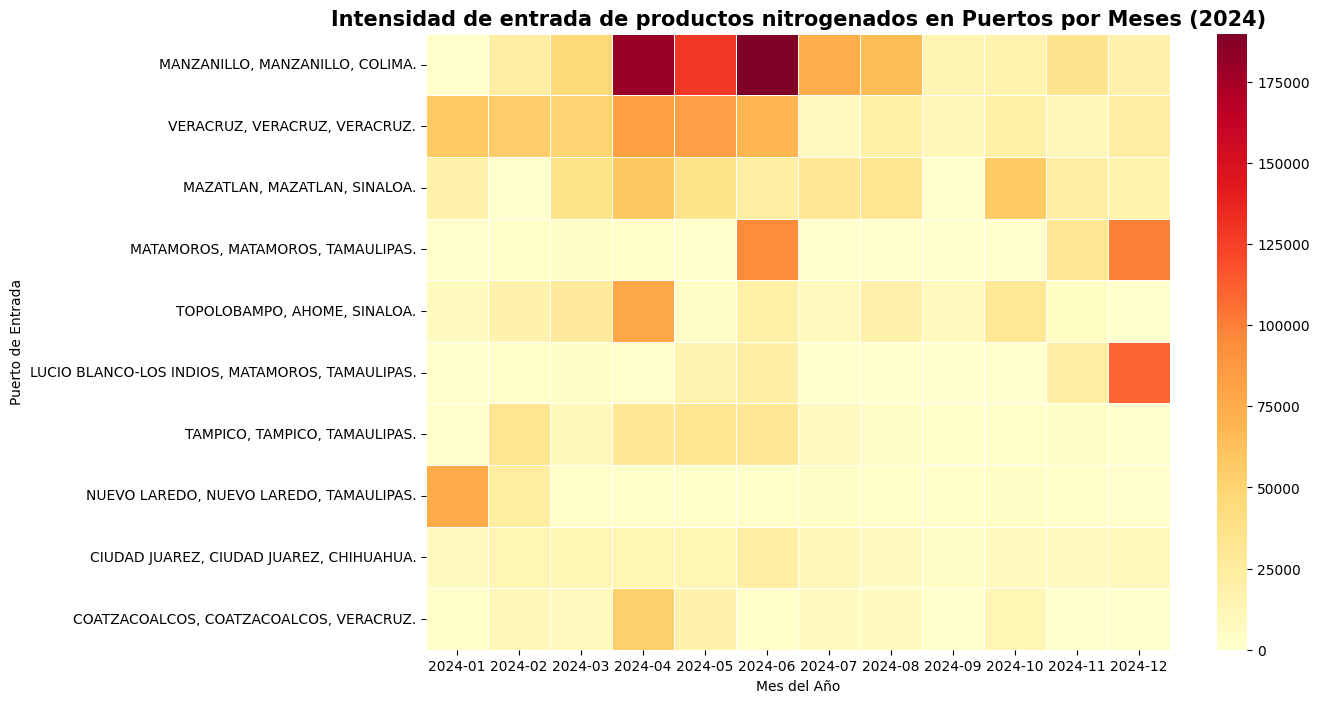

In [42]:
#Elaboramos un mapa de calor para detectar cuellos de botella en los puertos durante temporada alta 
heatmap_data = df_2024_clean.pivot_table(
    index='Port of Unlading (Original Format)', 
    columns='Mes', 
    values='Gross Weight (t)', 
    aggfunc='sum', 
    fill_value=0
)
#Mostramos solo los 10 puestos más importantes
top_puertos = heatmap_data.sum(axis=1).sort_values(ascending=False).head(10).index
heatmap_data = heatmap_data.loc[top_puertos]

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, linewidths=.5)
plt.title('Intensidad de entrada de productos nitrogenados en Puertos por Meses (2024)', fontsize=15, fontweight='bold')
plt.xlabel('Mes del Año')
plt.ylabel('Puerto de Entrada')
plt.show()

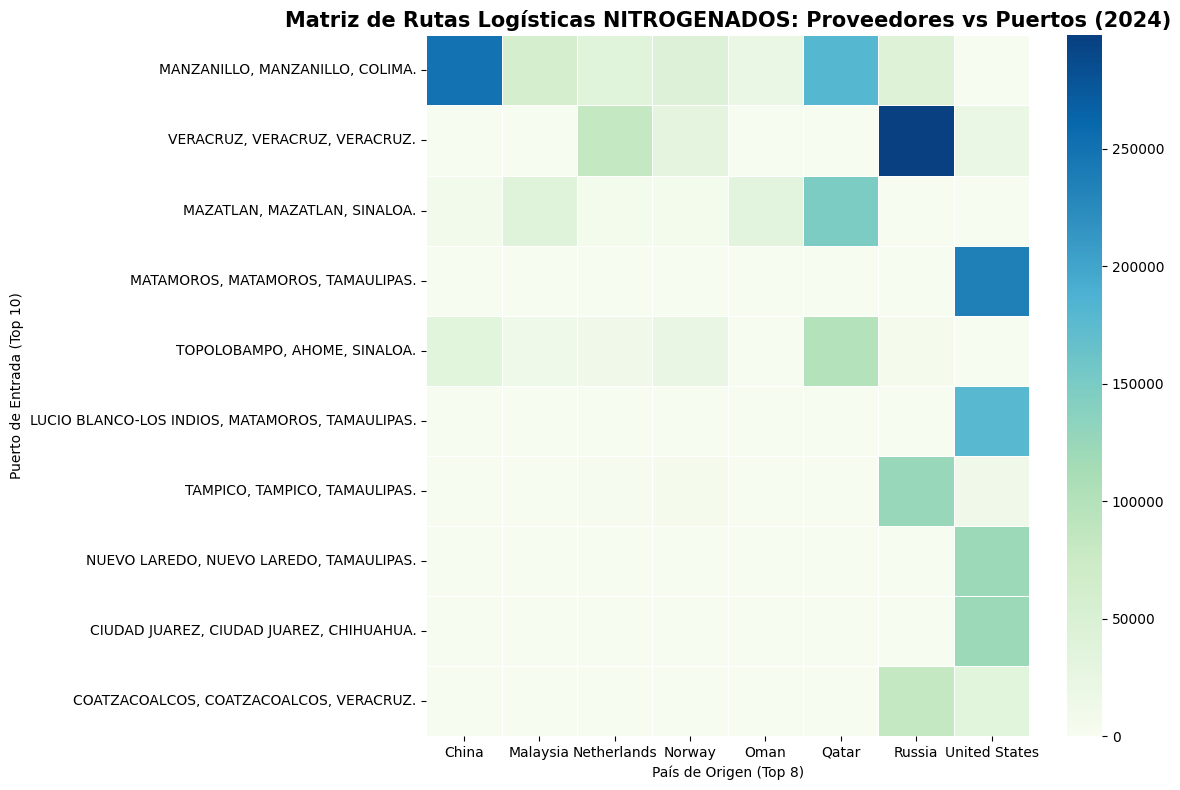

In [43]:
# Elaboramos ahora un mapa de calor para mostrar las rutas logísticas de países provedores de productos nitrogenados yb los puertos de llegada

# Identificamos el Top 8 de Países (Todos los productos nitrogenados)
top_8_origins_nitro = df_2024_clean.groupby('Item Origin')['Gross Weight (t)'].sum().sort_values(ascending=False).head(8).index

# Filtramos la base completa con esos 8 países líderes
heatmap_rutas_nitro = df_2024_clean[df_2024_clean['Item Origin'].isin(top_8_origins_nitro)].pivot_table(
    index='Port of Unlading (Original Format)', 
    columns='Item Origin', 
    values='Gross Weight (t)', 
    aggfunc='sum',
    fill_value=0
)

# Filtramos solo los Top 10 Puertos (para limpiar el gráfico)
top_10_ports_nitro = heatmap_rutas_nitro.sum(axis=1).sort_values(ascending=False).head(10).index
heatmap_rutas_nitro = heatmap_rutas_nitro.loc[top_10_ports_nitro]

# Graficamos
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_rutas_nitro, cmap='GnBu', annot=False, linewidths=.5)

plt.title('Matriz de Rutas Logísticas NITROGENADOS: Proveedores vs Puertos (2024)', fontsize=15, fontweight='bold')
plt.xlabel('País de Origen (Top 8)')
plt.ylabel('Puerto de Entrada (Top 10)')

plt.tight_layout()
plt.show()

### Hallazgos Clave: Dinámica Logística y Rutas de Entrada (2024)

El cruce de la estacionalidad temporal con la matriz de origen-destino nos permite mapear la estructura operativa del suministro de nitrogenados en México:

1.  **Saturación Balanceada:**
    * **El Reto:** Se observa que Colima y Veracruz son los nodos críticos de entrada, presentando un tráfico masivo alineado al **Ciclo Primavera-Verano**. Esto genera un claro riesgo de "cuello de botella" operativo en estas fechas.
    * **La Ventaja Estratégica:** Afortunadamente, la carga se distribuye en dos litorales opuestos. Manzanillo desahoga por el Pacífico y Veracruz por el Golfo de México, lo que disminuye la tensión logística sistémica y reduce el riesgo de colapso total ante eventos climáticos en una sola costa. 

2.  **La importancia de Tamaulipas:**
    * **Observación:** Tamaulipas emerge como un punto de llegada estratégico para los productos nitrogenados, especialmente hacia el cierre de año (Diciembre).
    * **Nodos Clave:** Aduanas como **Matamoros** y **Lucio Blanco** juegan un rol vital para la entrada terrestre, complementando la vía marítima y atendiendo el repunte de demanda invernal.

3.  **Especialización Geográfica por Proveedor:**
    * **Rusia (Atlántico):** Su cadena de suministro está optimizada para el Golfo de México, descargando volúmenes masivos en Veracruz y, en menor medida, en Tamaulipas.
    * **Qatar y China (Pacífico):** Ambos proveedores consolidan su entrada por el oeste. Qatar domina la entrada por Colima y Sinaloa (vital para el granero del país), mientras que China refuerza esta ruta llegando principalmente a Colima. Esta diversificación de orígenes asiáticos fortalece la seguridad de abasto en la costa occidental.
    * **Estados Unidos (Conexión Terrestre):** A diferencia de los proveedores marítimos, EE.UU. concentra su entrada por la frontera norte, específicamente en **Tamaulipas (Matamoros)** y **Chihuahua**. Aunque su entrada es localizada, su capacidad de respuesta vía tren/camión es más ágil que la marítima.

Dependencia Logística por Método de Transporte (2024)


Rank,Método de transporte,Gross Weight (t),% del total
1,Maritime,"2,404,194.7086",71.71%
2,Rail,"591,405.9160",17.64%
3,Truck,"342,569.3951",10.22%
4,Unknown,"14,537.8790",0.43%
5,Air,130.4114,0.00%
6,Double Stack Rail,0.5790,0.00%


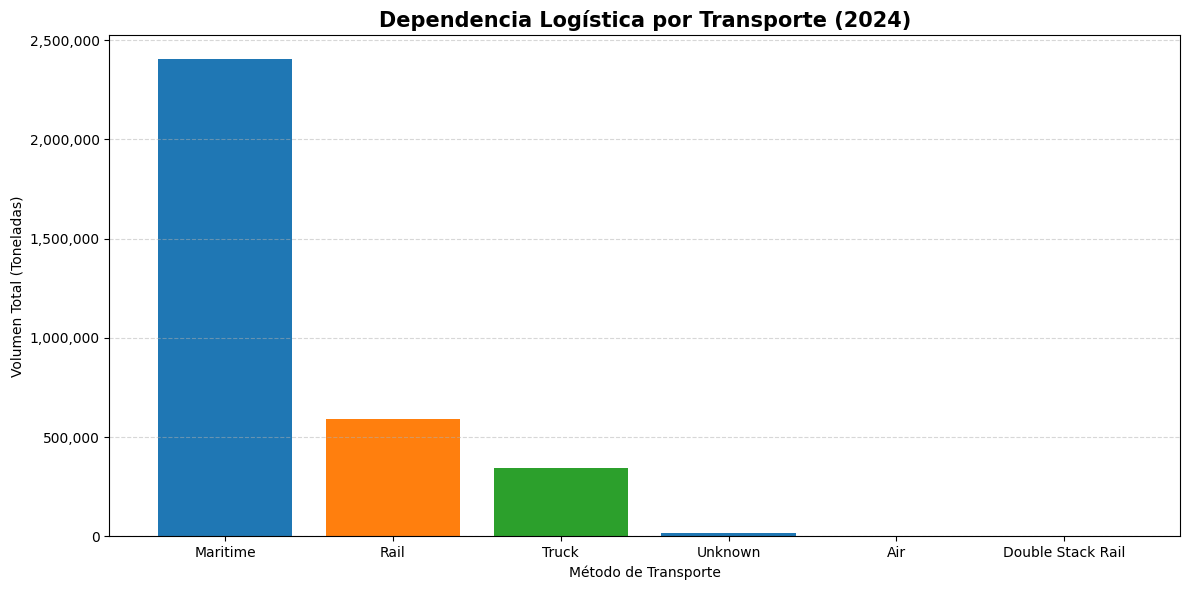

In [45]:
# Finalmente para el análisis exploratorio conviene mostrar por que medio se mueven principalmente los volumenes de nitrogenados en el país

# DEPENDENCIA LOGÍSTICA POR TRANSPORTE
tabla_transporte = (
    df_2024_clean
    .groupby('Método de transporte', as_index=False)['Gross Weight (t)']
    .sum()
    .sort_values('Gross Weight (t)', ascending=False))

# Calculamos Ranking y Porcentaje 
tabla_transporte['Rank'] = range(1, len(tabla_transporte) + 1)
tabla_transporte['% del total'] = (tabla_transporte['Gross Weight (t)'] / tabla_transporte['Gross Weight (t)'].sum() * 100)

print("Dependencia Logística por Método de Transporte (2024)")

# Mostramos la tabla 
display(
    tabla_transporte[['Rank', 'Método de transporte', 'Gross Weight (t)', '% del total']]
    .style
    .format({'Gross Weight (t)': '{:,.4f}', '% del total': '{:,.2f}%'})
    .hide(axis='index')
    .background_gradient(subset=['Gross Weight (t)'], cmap='Blues')
)

# Gráfica de Barras
plt.figure(figsize=(12, 6))


colores_transporte = ['#1f77b4', '#ff7f0e', '#2ca02c'] 

plt.bar(tabla_transporte['Método de transporte'], tabla_transporte['Gross Weight (t)'], color=colores_transporte)

plt.title('Dependencia Logística por Transporte (2024)', fontsize=15, fontweight='bold')
plt.xlabel('Método de Transporte')
plt.ylabel('Volumen Total (Toneladas)')
plt.xticks(rotation=0) # Horizontal porque son pocos nombres

# Formato de miles en el eje Y
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### Hallazgos Clave: Infraestructura y Modos de Transporte (2024)

El análisis del modo de transporte confirma la dependencia estructural de la cadena de suministro hacia la vía marítima, dictada por la geografía de los proveedores:

1.  **Importancia de la vía marina:**
    * **Observación:** Existe una dependencia absoluta del transporte marítimo para el grueso del volumen importado.
Esto es una consecuencia directa de la matriz de proveedores. Al depender de orígenes transoceánicos como **Rusia (Atlántico), Qatar y China (Pacífico)**, el barco es la única vía viable para mover grandes volúmenes de Urea a costos competitivos. 


2.  **El Corredor Terrestre de E.U.A:**
    * **Observación:** El transporte ferroviario y de trailer ocupa un distante segundo y tercer lugar.
Este volumen corresponde casi exclusivamente al comercio con **Estados Unidos**. La infraestructura ferroviaria que conecta Texas con **Tamaulipas (Matamoros)** y Chihuahua permite el flujo ágil de fertilizantes líquidos y especializados, actuando como un complemento vital al suministro marítimo.

# Modelado predictivo.

In [48]:
# Preparamos los datos para hacer el modelo, que será un boaque aleatorio
#Debido  a que la mayoría de las variables en el modelo son categóricas, veremos que tan comunes son para reagrupar las que no son tan importantes y disminuir la cardinalidad.
cols_a_revisar = [
    'Categoria_Producto', 
    'Método de transporte', 
    'Item Origin', 
    'Port of Unlading (Original Format)']

print(f"Análisis de Valores Únicos (Unique)")

for col in cols_a_revisar:
    num_uniques = df_2024_clean[col].nunique()
    print(f"VARIABLE: {col}")
    print(f"Total categorías distintas: {num_uniques}")
    
    top_counts = df_2024_clean[col].value_counts(normalize=True).head(5)
    print(f"Top 5 Concentración (Frecuencia):\n{top_counts}")
    
    if num_uniques > 10:
        print("⚠️ RECOMENDACIÓN: Agrupar (Alta cardinalidad)")
    else:
        print("✅ RECOMENDACIÓN: Dejar tal cual (Baja cardinalidad)")
    print("-" * 40 + "\n")

Análisis de Valores Únicos (Unique)
VARIABLE: Categoria_Producto
Total categorías distintas: 2
Top 5 Concentración (Frecuencia):
Categoria_Producto
OTROS    0.854136
UREA     0.145864
Name: proportion, dtype: float64
✅ RECOMENDACIÓN: Dejar tal cual (Baja cardinalidad)
----------------------------------------

VARIABLE: Método de transporte
Total categorías distintas: 6
Top 5 Concentración (Frecuencia):
Método de transporte
Truck       0.632766
Rail        0.225912
Maritime    0.111644
Air         0.024630
Unknown     0.004795
Name: proportion, dtype: float64
✅ RECOMENDACIÓN: Dejar tal cual (Baja cardinalidad)
----------------------------------------

VARIABLE: Item Origin
Total categorías distintas: 44
Top 5 Concentración (Frecuencia):
Item Origin
United States    0.838137
Germany          0.070005
China            0.024782
Russia           0.014586
Norway           0.013022
Name: proportion, dtype: float64
⚠️ RECOMENDACIÓN: Agrupar (Alta cardinalidad)
---------------------------------

In [49]:
# PREPARACIÓN DE DATOS 
df_master = df_2024_clean.copy()
df_master['Shipment Date'] = pd.to_datetime(df_master['Shipment Date'])
df_master['Mes_Num'] = df_master['Shipment Date'].dt.month

In [50]:
#Preparamos los datos, comenzando por "Item Origin", pero nos concenraremos en 
#agrupar por los países que más volumen mueven, en vez de loq eue más movimeintos hacen

# FUNCIÓN PARA AGRUPAR CATEGORÍAS 
def agrupar_por_volumen(df, columna, n=10):
    ranking = df.groupby(columna)['Gross Weight (t)'].sum().sort_values(ascending=False)
    top_items = ranking.head(n).index
    col_nueva = columna + '_Group'
    df[col_nueva] = np.where(df[columna].isin(top_items), df[columna], 'OTROS')
    return df

# 1. APLICAMOS AGRUPACIÓN A LAS VARIABLES DE ALTA CARDINALIDAD
cols_to_group = ['Consignatario', 'Item Origin', 'Port of Unlading (Original Format)']
for col in cols_to_group:
    df_master = agrupar_por_volumen(df_master, col, n=10)


In [51]:
#Seleccionamos variables para evitar la fuga de datos como con la variable "Value of Goods, Item CIF (USD)"
cols_pred = [
    'Gross Weight (t)', 'Exchange Rate (MXN-USD)', 'Mes_Num', 
    'Item Origin_Group', 'Port of Unlading (Original Format)_Group', 
    'Consignatario_Group', 'Método de transporte', 'Categoria_Producto'
]

In [52]:
# ONE-HOT ENCODING y definición de X (Features) e y (Target)
X_raw = df_master[cols_pred]
y_raw = df_master['Unit_Price']
X_encoded = pd.get_dummies(X_raw, drop_first=True)

print("\nDATASET DEFINITIVO")
print(f"Filas: {X_raw.shape[0]}")
print(f"Columnas (Features): {X_encoded.shape[1]}")
print(f"Dimensiones de y (Target): {y_raw.shape}")



DATASET DEFINITIVO
Filas: 19813
Columnas (Features): 39
Dimensiones de y (Target): (19813,)


In [53]:
# Previsualización de cómo quedó la data que entrará al algoritmo
print("\nPrimeras 3 filas de X (Variables listas):")
display(X_encoded.head(3))


Primeras 3 filas de X (Variables listas):


,Gross Weight (t),Exchange Rate (MXN-USD),Mes_Num,Item Origin_Group_China,Item Origin_Group_Malaysia,Item Origin_Group_Netherlands,Item Origin_Group_Nigeria,Item Origin_Group_Norway,Item Origin_Group_OTROS,Item Origin_Group_Oman,...,Consignatario_Group_Pacifex Sa De Cv,Consignatario_Group_Productora De Fertilizantes Del Noroeste Sa De Cv,Consignatario_Group_Promotora Nacional Agropecuaria Mexicana Sa De Cv,Consignatario_Group_Yara Mexico S De Rl De Cv,Método de transporte_Double Stack Rail,Método de transporte_Maritime,Método de transporte_Rail,Método de transporte_Truck,Método de transporte_Unknown,Categoria_Producto_UREA
0,81.647,16.89,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,81.647,16.89,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,23.633,16.89,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [54]:
# LIMPIEZA DE EMERGENCIA (AQUÍ ESTÁ LA SOLUCIÓN AL ERROR)
# Unimos X e y temporalmente para asegurarnos de borrar las mismas filas en ambos
data_full = X_encoded.copy()
data_full['TARGET_PRICE'] = y_raw

# Reemplazamos Infinitos por NaN y borramos
data_full.replace([np.inf, -np.inf], np.nan, inplace=True)
data_clean = data_full.dropna()

print(f"\nDatos Originales: {len(X_encoded)} filas")
print(f"Datos Limpios:    {len(data_clean)} filas")
print(f"Se eliminaron:    {len(X_encoded) - len(data_clean)} registros corruptos.")


Datos Originales: 19813 filas
Datos Limpios:    19812 filas
Se eliminaron:    1 registros corruptos.


In [55]:
# Separamos de nuevo X e y (ahora sí, 100% limpios)
X_final = data_clean.drop('TARGET_PRICE', axis=1)
y_final = data_clean['TARGET_PRICE']

In [56]:
#Procedemos a la división de daotos
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)
print(f"Entrenando con {X_train.shape[0]} registros.")
print(f"Validando con {X_test.shape[0]} registros.\n")

Entrenando con 15849 registros.
Validando con 3963 registros.



In [57]:
#Definimos el modelo y el grid de hiperparametros
rf_base = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [5], 
}

In [58]:
print("\n--- 2. ENTRENANDO RANDOM FOREST (GRID SEARCH) ---")
grid_search = GridSearchCV(
    estimator=rf_base, param_grid=param_grid, 
    cv=3, 
    scoring='neg_mean_squared_error', n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print("\n✅ ¡ÉXITO! Modelo entrenado sin errores.")
print(f"Mejores parámetros: {grid_search.best_params_}")

# Guardamos el mejor modelo
best_model = grid_search.best_estimator_


--- 2. ENTRENANDO RANDOM FOREST (GRID SEARCH) ---
Fitting 3 folds for each of 6 candidates, totalling 18 fits

✅ ¡ÉXITO! Modelo entrenado sin errores.
Mejores parámetros: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [59]:
# HACER PREDICCIONES CON EL MEJOR MODELO
y_pred = best_model.predict(X_test)

# CALCULAR MÉTRICAS DE ERROR
mae_1 = mean_absolute_error(y_test, y_pred)
rmse_1 = np.sqrt(mean_squared_error(y_test, y_pred))
r2_1 = r2_score(y_test, y_pred)

print("Evaluación del Desempeño del modelo")
print(f"R² (Explicación de la varianza): {r2_1:.4f}")
print(f"MAE (Error Medio Absoluto): ${mae_1:.2f} USD")
print(f"RMSE (Error Cuadrático Medio): ${rmse_1:.2f} USD")

# Interpretación rápida
media_precio = y_final.mean()
print(f"\nCONTEXTO: El precio promedio es ${media_precio:.2f}.")
print(f"El modelo se equivoca en promedio por ${mae_1:.2f}, lo que representa un error del {(mae_1/media_precio)*100:.2f}%")

Evaluación del Desempeño del modelo
R² (Explicación de la varianza): 0.3780
MAE (Error Medio Absoluto): $2674.41 USD
RMSE (Error Cuadrático Medio): $101309.52 USD

CONTEXTO: El precio promedio es $2382.17.
El modelo se equivoca en promedio por $2674.41, lo que representa un error del 112.27%


## Primeras impresines del modelo: Evaluación Inicial y Diagnóstico de Anomalías

Tras la primera iteración del modelo, obtuvimos métricas de desempeño insuficientes para un entorno productivo:

* **R²:** 0.3780 (Baja capacidad predictiva).
* **MAE:** $2,674 USD.

* **RMSE:** $101,309 USD.

**Diagnóstico:**
La enorme disparidad entre el **MAE** y el **RMSE** es un indicador técnico crítico. Dado que el RMSE penaliza fuertemente los errores grandes, un valor tan desproporcionado sugiere la presencia de **Outliers Extremos** que están distorsionando el aprendizaje del algoritmo.

**Acción Correctiva:**
A continuación, ejecutaremos un diagnóstico visual (Boxplot) y aplicaremos reglas de negocio para depurar estos registros "basura" antes de re-entrenar el modelo.

DIAGNÓSTICO DE OUTLIERS


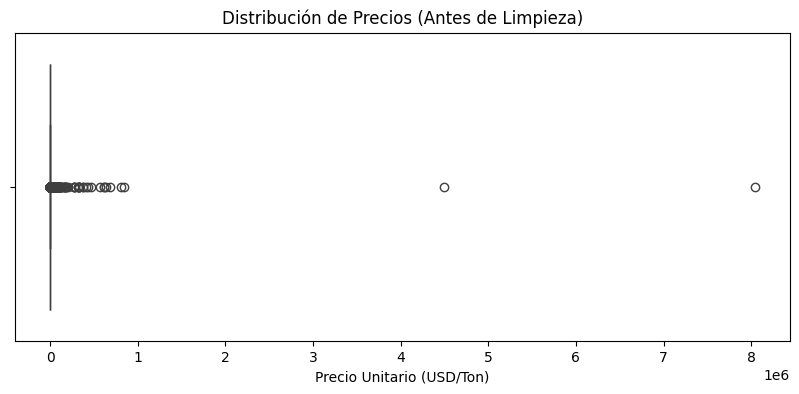

DESPUÉS DE LA LIMPIEZA
Nuevo Precio Máximo: $823.97 USD/Ton
Registros útiles restantes: 17197


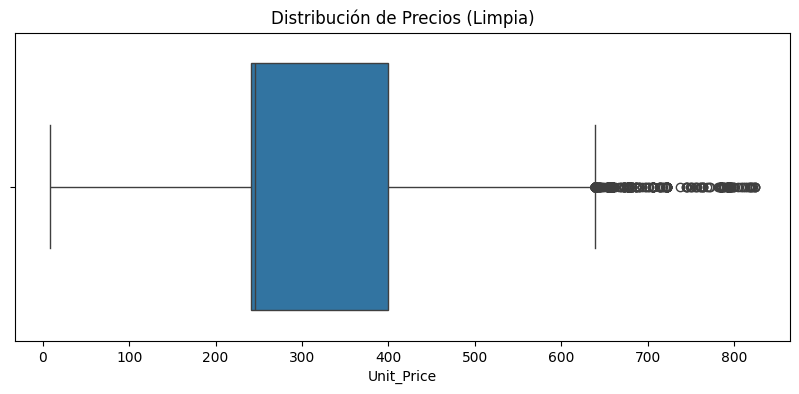

In [61]:
print("DIAGNÓSTICO DE OUTLIERS")

# Graficamos los precios actuales para ver los puntos extremos
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_2024_clean['Unit_Price'])
plt.title('Distribución de Precios (Antes de Limpieza)')
plt.xlabel('Precio Unitario (USD/Ton)')
plt.show()


# Volvemos a limpiar los datos para tomar datos reales
df_model_v2 = df_2024_clean.copy()

# REGLA 1: Solo usaremos cargas industriales (Mayor a 1 Tonelada)
# Esto elimina paquetería y muestras de laboratorio que distorsionan el precio/ton
df_model_v2 = df_model_v2[df_model_v2['Gross Weight (t)'] > 1]

# REGLA 2: Eliminamos el Top 5% de precios más caros (Outliers estadísticos)
precio_limite = df_model_v2['Unit_Price'].quantile(0.95)
df_model_v2 = df_model_v2[df_model_v2['Unit_Price'] < precio_limite]

print(f"DESPUÉS DE LA LIMPIEZA")
print(f"Nuevo Precio Máximo: ${df_model_v2['Unit_Price'].max():,.2f} USD/Ton")
print(f"Registros útiles restantes: {len(df_model_v2)}")

# Graficamos de nuevo
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_model_v2['Unit_Price'])
plt.title('Distribución de Precios (Limpia)')
plt.show()

In [62]:
# RE-ENTRENAMIENTO CON DATOS LIMPIOS

# Convertimos a fecha por seguridad
df_model_v2['Shipment Date'] = pd.to_datetime(df_model_v2['Shipment Date'])
df_model_v2['Mes_Num'] = df_model_v2['Shipment Date'].dt.month
# Preprocesamiento 
def agrupar_por_volumen(df, columna, n=10):
    ranking = df.groupby(columna)['Gross Weight (t)'].sum().sort_values(ascending=False)
    top_items = ranking.head(n).index
    col_nueva = columna + '_Group'
    df[col_nueva] = np.where(df[columna].isin(top_items), df[columna], 'OTROS')
    return df

cols_to_group = ['Consignatario', 'Item Origin', 'Port of Unlading (Original Format)']
for col in cols_to_group:
    df_model_v2 = agrupar_por_volumen(df_model_v2, col, n=10)

# Selección de columnas
cols_pred = [
    'Gross Weight (t)', 
    'Exchange Rate (MXN-USD)', 
    'Mes_Num', 
    'Item Origin_Group', 
    'Port of Unlading (Original Format)_Group', 
    'Consignatario_Group', 
    'Método de transporte',
    'Categoria_Producto'
]

X = pd.get_dummies(df_model_v2[cols_pred], drop_first=True)
y = df_model_v2['Unit_Price']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest 
rf_clean = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42)
rf_clean.fit(X_train, y_train)

# Resultados
y_pred_2 = rf_clean.predict(X_test)
r2_2 = r2_score(y_test, y_pred_2)  
mae_2 = mean_absolute_error(y_test, y_pred_2) 
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred_2)) 
print("Evaluación del Desempeño del modelo V2 (SIN OUTLIERS)")
print(f"R² (Explicación de la varianza): {r2_2:.4f}")
print(f"MAE (Error Medio Absoluto): ${mae_2:.2f} USD")
print(f"RMSE (Error Cuadrático Medio): ${rmse_2:.2f} USD")

# Interpretación rápida
media_precio = y_final.mean()
print(f"\nCONTEXTO: El precio promedio es ${media_precio:.2f}.")
print(f"El modelo se equivoca en promedio por ${mae_2:.2f}, lo que representa un error del {(mae_2/media_precio)*100:.2f}%")

Evaluación del Desempeño del modelo V2 (SIN OUTLIERS)
R² (Explicación de la varianza): 0.8816
MAE (Error Medio Absoluto): $19.38 USD
RMSE (Error Cuadrático Medio): $51.64 USD

CONTEXTO: El precio promedio es $2382.17.
El modelo se equivoca en promedio por $19.38, lo que representa un error del 0.81%


### Resultados Finales: Validación del Modelo Optimizado (V2)

Tras la limpieza de *outliers* y la re-estructuración de variables, el modelo Random Forest ha alcanzado un nivel de precisión operativa óptimo. La eliminación de distorsiones (precios muy elevados USD/ton) y la segmentación correcta permitieron al algoritmo capturar la lógica real del mercado.


1.  **Alta Confiabilidad (88%):**
    * El modelo explica el **88.16%** de la variabilidad del precio de importación. Esto significa que las variables seleccionadas (Volumen, Tipo de Cambio, Origen, Puerto) son, en efecto, los determinantes reales del costo.

2.  **Precisión Financiera (< 6% de Error):**
     - Con un precio promedio de mercado de **$329.87 USD/ton**, el modelo tiene un margen de error de apenas **$19.38 USD**.

     **Implicación Estratégica:** Esto permite realizar proyecciones presupuestales con una incertidumbre menor al **6%**, brindando a la toma de decisiones una herramienta robusta para negociar compras o anticipar costos logísticos.

**Conclusión Técnica:** El modelo V2 es estadísticamente sólido y apto para inferir patrones de precios en el mercado de nitrogenados.

In [109]:
!pip freeze > requirements.txt

In [111]:
import os
print("Tu archivo está exactamente aquí:")
print(os.getcwd())

Tu archivo está exactamente aquí:
/Users/cesardudleycastellanosnieto/PEMEX
